In [1]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

Things to fix:

1. negative drifting baseline
2. blank?
3. be smarter about number of data points used to fit

In [2]:
mutant = 'wt'
#mutant = 'N214A'
#mutant = 'Q256A'
#mutant = 'S284A'

if mutant == 'wt':
    ks = KineticsSeries('./wt/wt.yaml', prefix='./wt')
elif mutant == 'N214A':
    ks = KineticsSeries('./N214A/n214a.yaml', prefix='./N214A')
elif mutant == 'Q256A':
    ks = KineticsSeries('./Q256A/q256a.yaml', prefix='./Q256A')
elif mutant == 'S284A':
    ks = KineticsSeries('./S284A/s284a.yaml', prefix='./S284A')
else:
    raise NameError()

Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluding E=20.00 / S=20.00
Loading: 210420_10µM_MproWT.csv...
Loading: 210420_5_and_2µM_MproWT.csv...


In [3]:
ps = [2.0, 5.0, 10.0, 20.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

ks.fit_v0()

4 7


<IPython.core.display.Javascript object>


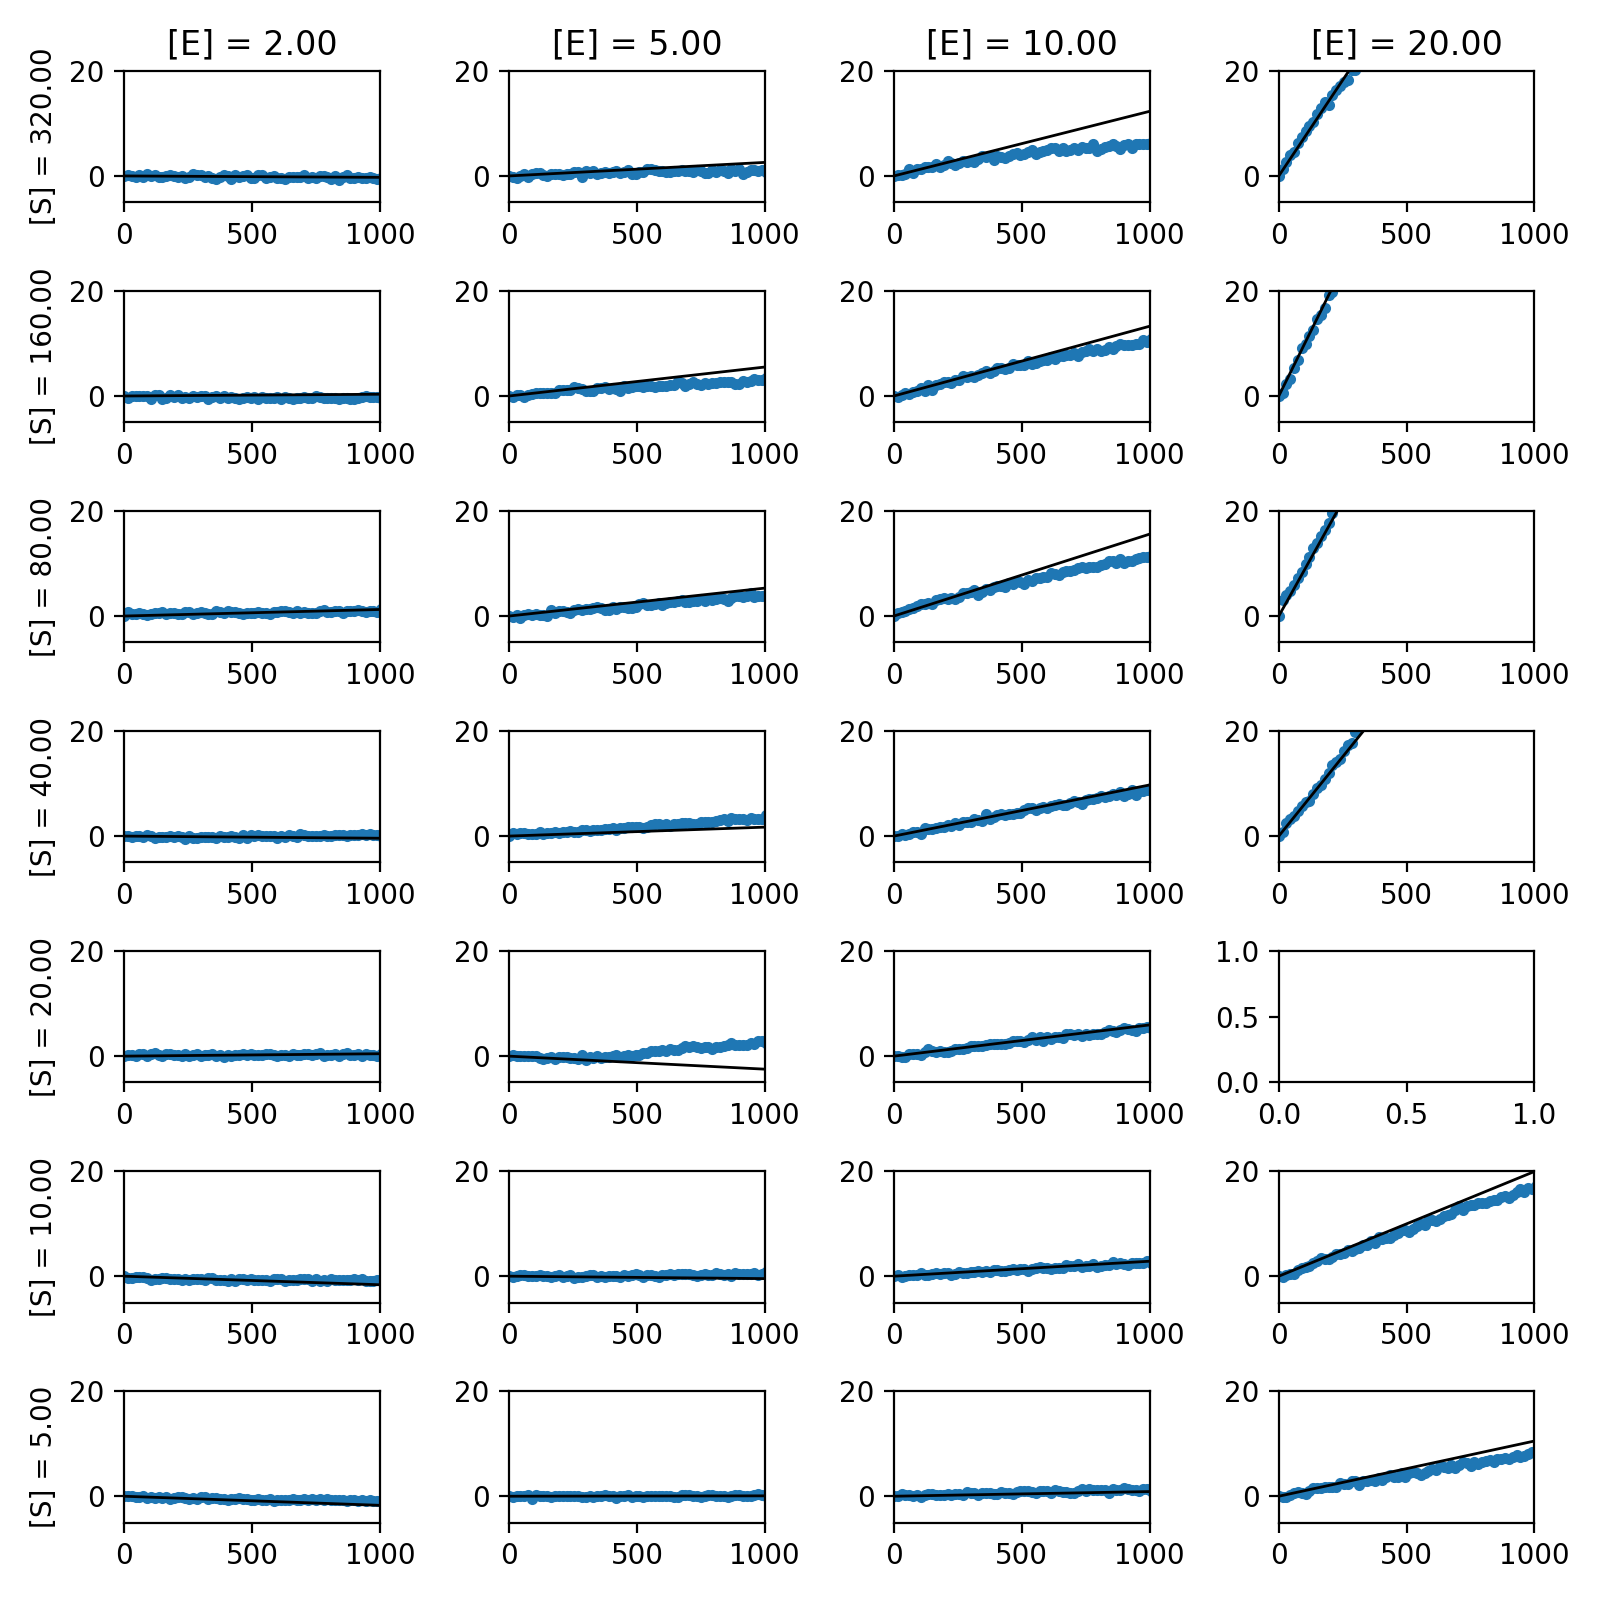

In [4]:
fig, axes = plt.subplots(n_s, n_p, figsize=(8,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if entry['exclude']:
                continue
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            axes[i_s, i_p].plot(t, entry['timeseries'] - entry['timeseries'][0], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1)
            
            axes[i_s, i_p].set_xlim([0, 1000])
            axes[i_s, i_p].set_ylim([-5, 20])
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
                
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)

plt.tight_layout()
plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()

In [5]:
# QUESTIONABLE!
# seems we have a negative-drifting baseline...

#v0s = v0s + 2

<IPython.core.display.Javascript object>


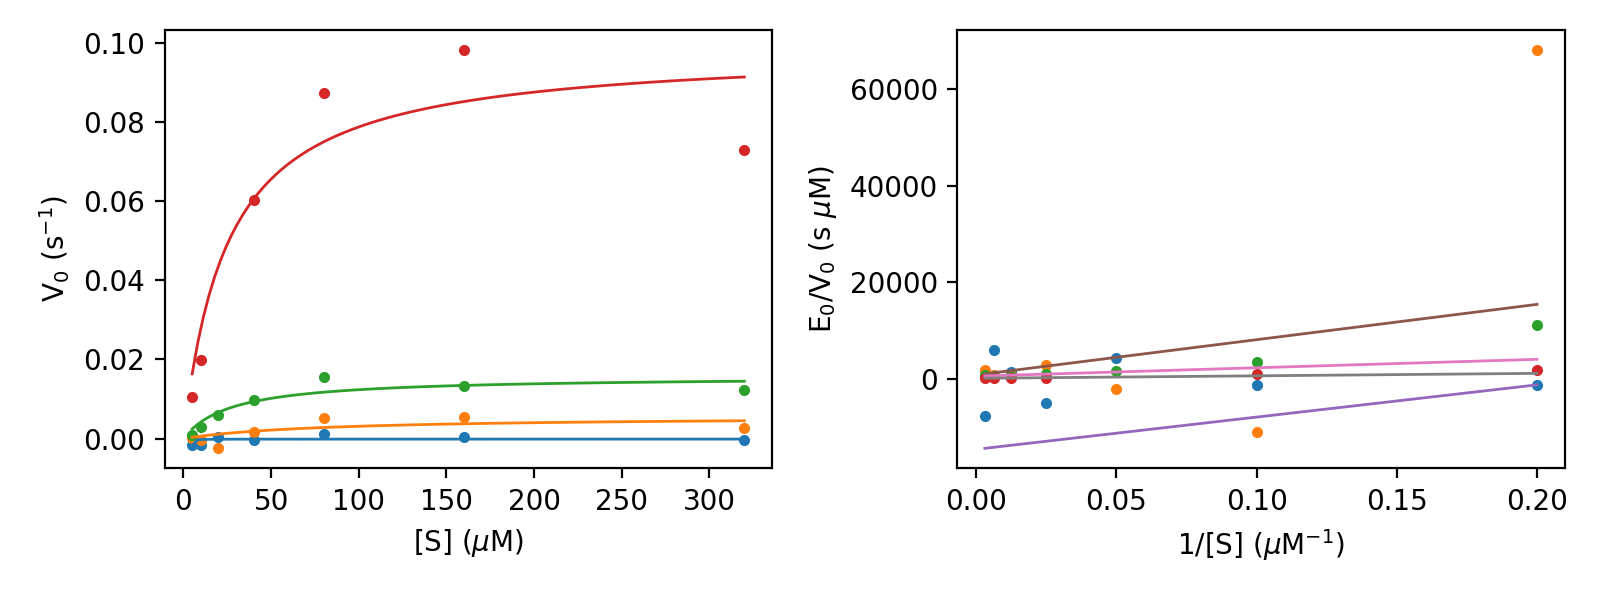

[E]	k_cat		K_m
---	-----		---
2.00	-6.92e-05	-4.60e+00
5.00	1.13e-03	8.24e+01
10.00	1.57e-03	2.74e+01
20.00	4.93e-03	2.52e+01


In [6]:
kinetic_params = np.zeros([n_p, 3])

plt.figure(figsize=(8,3))

ax1 = plt.subplot(121)
for p in ps:
    s0s, v0s = ks.get_set_v0s(p, ss)
    ax1.plot(s0s, v0s, '.')
ax1.set_xlabel('[S] ($\mu$M)')
ax1.set_ylabel('V$_0$ (s$^{-1}$)')


# Lineweaver-Burk
plt.gca().set_prop_cycle(None)

ax2 = plt.subplot(122)
for p in ps:
    s0s, v0s = ks.get_set_v0s(p, ss)
    ax2.plot(1/s0s, p/v0s, '.')
ax2.set_xlabel('1/[S] ($\mu$M$^{-1}$)')
ax2.set_ylabel('E$_0$/V$_0$ (s $\mu$M)')


# fit
print('[E]\tk_cat\t\tK_m')
print('---\t-----\t\t---')

for i,p in enumerate(ps):
    
    s0s, v0s = ks.get_set_v0s(p, ss)
    
    k_cat, K_m = fit_mm(v0s, s0s, p)
    print('%.2f\t%.2e\t%.2e' % (p, k_cat, K_m))
    kinetic_params[i,:] = np.array([p, k_cat, K_m])
    
    S = np.linspace(ss.min(), ss.max(), 100)
    V_fit = mm(p, S, k_cat, K_m)
    ax1.plot(S, V_fit, lw=1)
    ax2.plot(1.0/S, p/V_fit, lw=1)

    
plt.tight_layout()
plt.savefig('figures/%s_lineweaver_burk.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


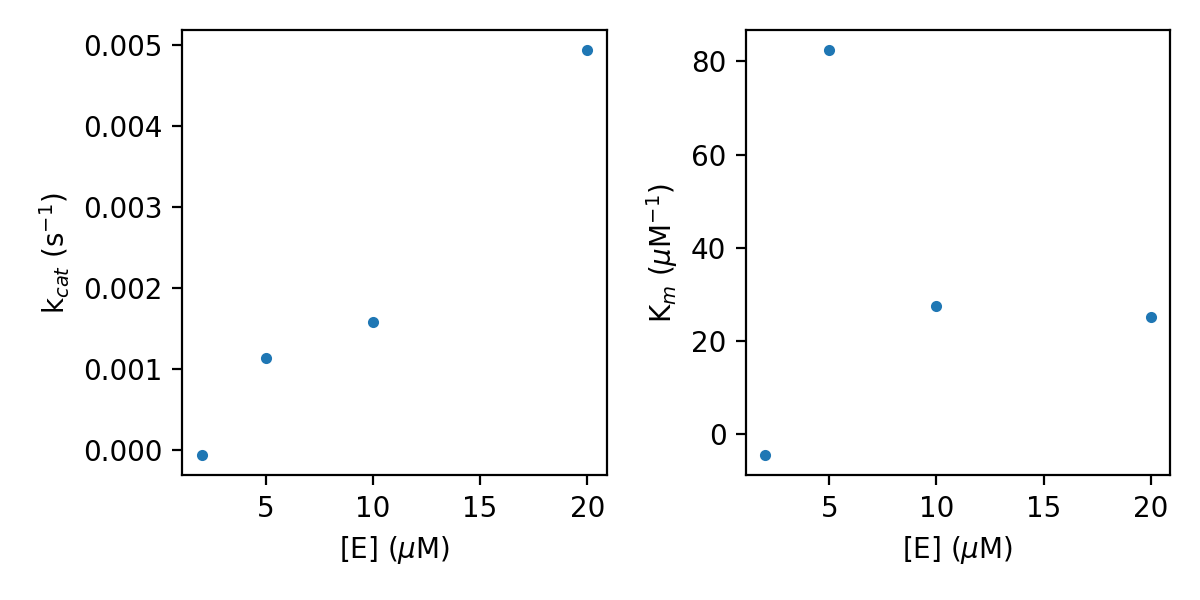

In [7]:
plt.figure(figsize=(6,3))

plt.subplot(121)
plt.plot(kinetic_params[:,0], kinetic_params[:,1], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')

plt.subplot(122)
plt.plot(kinetic_params[:,0], kinetic_params[:,2], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M$^{-1}$)')

plt.tight_layout()
plt.show()

## Haldane

<IPython.core.display.Javascript object>


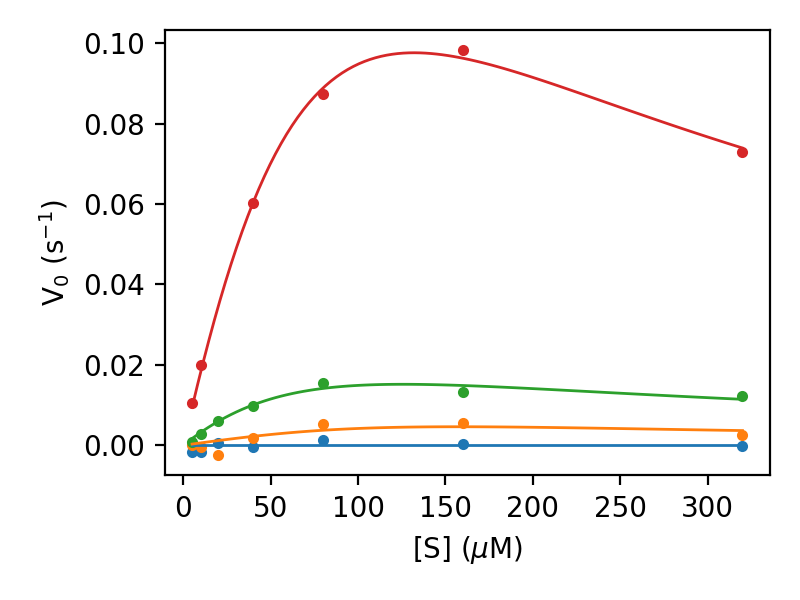

[E]	k_cat		K_m		K_i
---	-----		---		---
2.00	1.85e-06	1.61e+02	1.97e-04
5.00	7.10e-02	5.98e+03	4.13e+00
10.00	5.01e-03	1.45e+02	1.09e+02
20.00	2.09e-02	2.17e+02	8.03e+01


In [8]:
haldane_params = np.zeros([n_p, 4])

plt.figure(figsize=(4,3))

ax1 = plt.subplot(111)
for p in ps:
    s0s, v0s = ks.get_set_v0s(p, ss)
    ax1.plot(s0s, v0s, '.')
ax1.set_xlabel('[S] ($\mu$M)')
ax1.set_ylabel('V$_0$ (s$^{-1}$)')

# fit
print('[E]\tk_cat\t\tK_m\t\tK_i')
print('---\t-----\t\t---\t\t---')

plt.gca().set_prop_cycle(None)
for i,p in enumerate(ps):
    
    s0s, v0s = ks.get_set_v0s(p, ss)
    
    k_cat, K_m, K_i = fit_haldane(v0s, s0s, p)
    print('%.2f\t%.2e\t%.2e\t%.2e' % (p, k_cat, K_m, K_i))
    haldane_params[i,:] = np.array([p, k_cat, K_m, K_i])
    
    S = np.linspace(ss.min(), ss.max(), 100)
    V_fit = haldane(p, S, k_cat, K_m, K_i)
    ax1.plot(S, V_fit, lw=1)
    

plt.tight_layout()
#plt.savefig('figures/%s_haldane.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


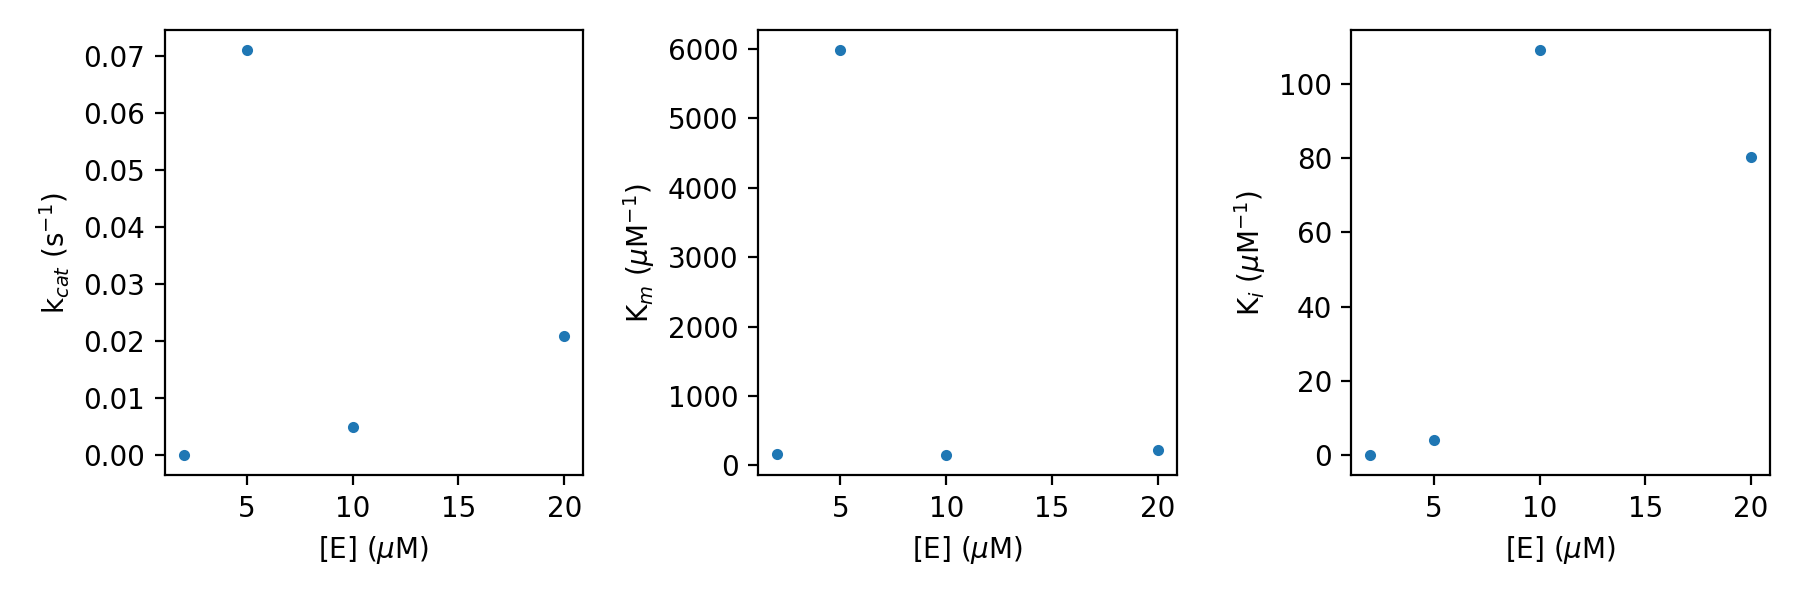

In [9]:
plt.figure(figsize=(9,3))

plt.subplot(131)
plt.plot(haldane_params[:,0], haldane_params[:,1], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')

plt.subplot(132)
plt.plot(haldane_params[:,0], haldane_params[:,2], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M$^{-1}$)')

plt.subplot(133)
plt.plot(haldane_params[:,0], haldane_params[:,3], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_i$ ($\mu$M$^{-1}$)')

plt.tight_layout()
plt.show()